# Assignment 7: Food Delivery Time Prediction (CNN + Validation)

## Objective
Predict whether delivery is **Fast (0)** or **Delayed (1)** using delivery, location, traffic, and weather features.

This notebook covers:
1. Preprocessing and feature engineering
2. CNN-based classification on image-like transformed features
3. Evaluation, K-fold validation, and hyperparameter tuning
4. Baseline comparison with Logistic Regression


In [1]:
import warnings
warnings.filterwarnings('ignore')

import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression

sns.set(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)


In [2]:
# Update path if needed
DATA_PATH = 'Food_Delivery_Time_Prediction.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
display(df.head())

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_count'))


Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34



Missing values:


,missing_count
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


## Phase 1: Data Preprocessing and Feature Engineering


In [3]:
work_df = df.copy()

# Parse latitude/longitude from tuple strings

def parse_lat_lon(value):
    try:
        lat, lon = ast.literal_eval(str(value))
        return float(lat), float(lon)
    except Exception:
        return np.nan, np.nan


def haversine_km(lat1, lon1, lat2, lon2):
    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan

    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

if 'Customer_Location' in work_df.columns:
    work_df[['customer_lat', 'customer_lon']] = work_df['Customer_Location'].apply(lambda x: pd.Series(parse_lat_lon(x)))
if 'Restaurant_Location' in work_df.columns:
    work_df[['restaurant_lat', 'restaurant_lon']] = work_df['Restaurant_Location'].apply(lambda x: pd.Series(parse_lat_lon(x)))

if set(['customer_lat','customer_lon','restaurant_lat','restaurant_lon']).issubset(work_df.columns):
    work_df['Haversine_Distance_km'] = work_df.apply(
        lambda r: haversine_km(r['customer_lat'], r['customer_lon'], r['restaurant_lat'], r['restaurant_lon']), axis=1
    )

# Time-based features
if 'Order_Time' in work_df.columns:
    rush_slots = {'Morning', 'Evening'}
    work_df['Rush_Hour'] = work_df['Order_Time'].astype(str).apply(lambda x: 1 if x in rush_slots else 0)

# Target creation: delayed vs fast using median delivery time
if 'Delivery_Time' not in work_df.columns:
    raise ValueError('Delivery_Time column is required for target creation.')

threshold = work_df['Delivery_Time'].median()
work_df['Delivery_Status'] = (work_df['Delivery_Time'] > threshold).astype(int)

print(f'Delay threshold (median Delivery_Time): {threshold:.2f}')
print('Class distribution (0=Fast, 1=Delayed):')
display(work_df['Delivery_Status'].value_counts().to_frame('count'))

# Weather impact analysis
if 'Weather_Conditions' in work_df.columns:
    weather_impact = work_df.groupby('Weather_Conditions').agg(
        Avg_Delivery_Time=('Delivery_Time', 'mean'),
        Delayed_Rate=('Delivery_Status', 'mean')
    ).sort_values('Delayed_Rate', ascending=False)
    print('Weather impact summary:')
    display(weather_impact)


Delay threshold (median Delivery_Time): 72.78
Class distribution (0=Fast, 1=Delayed):


,count
Delivery_Status,
0,100
1,100


Weather impact summary:


,Avg_Delivery_Time,Delayed_Rate
Weather_Conditions,,
Rainy,73.058947,0.561404
Sunny,69.479434,0.509434
Snowy,69.191250,0.458333
Cloudy,69.786667,0.452381


In [4]:
# Feature selection
model_df = work_df.copy()
drop_cols = [c for c in ['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Time'] if c in model_df.columns]
model_df = model_df.drop(columns=drop_cols)

X = model_df.drop(columns=['Delivery_Status'])
y = model_df['Delivery_Status']

num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tab = preprocessor.fit_transform(X_train_raw)
X_test_tab = preprocessor.transform(X_test_raw)

# Convert sparse to dense when needed
X_train_tab = X_train_tab.toarray() if hasattr(X_train_tab, 'toarray') else X_train_tab
X_test_tab = X_test_tab.toarray() if hasattr(X_test_tab, 'toarray') else X_test_tab

print('Tabular feature shape:', X_train_tab.shape)


Tabular feature shape: (160, 29)


## Phase 2: CNN Model

Note: this dataset is tabular, so we transform each sample into a small image-like matrix by padding and reshaping feature vectors.


In [5]:
# Transform tabular features into image-like tensors for CNN

def to_image_tensor(X):
    n_samples, n_features = X.shape
    side = int(np.ceil(np.sqrt(n_features)))
    padded_size = side * side

    X_padded = np.pad(X, ((0, 0), (0, padded_size - n_features)), mode='constant')
    X_img = X_padded.reshape(n_samples, side, side, 1)
    return X_img, side

X_train_img, side = to_image_tensor(X_train_tab)
X_test_img, _ = to_image_tensor(X_test_tab)

print('Image tensor shape:', X_train_img.shape, '| side:', side)


Image tensor shape: (160, 6, 6, 1) | side: 6


In [6]:
# Baseline model: Logistic Regression
log_reg = LogisticRegression(max_iter=1200, random_state=42)
log_reg.fit(X_train_tab, y_train)

y_pred_lr = log_reg.predict(X_test_tab)
y_prob_lr = log_reg.predict_proba(X_test_tab)[:, 1]

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_lr)
lr_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'F1': f1_score(y_test, y_pred_lr, zero_division=0),
    'ROC-AUC': auc(fpr_l, tpr_l)
}

print('Logistic Regression Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Fast (0)', 'Delayed (1)'], zero_division=0))
print(lr_metrics)


Logistic Regression Report:
              precision    recall  f1-score   support

    Fast (0)       0.50      0.55      0.52        20
 Delayed (1)       0.50      0.45      0.47        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.50      0.50      0.50        40

{'Model': 'Logistic Regression', 'Accuracy': 0.5, 'Precision': 0.5, 'Recall': 0.45, 'F1': 0.47368421052631576, 'ROC-AUC': 0.485}


In [7]:
# CNN training and evaluation (with robust fallback)
cnn_metrics = None
y_pred_cnn = None
y_prob_cnn = None
history = None
best_cnn_config = None
cnn_available = False
mlp_fallback = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
    from tensorflow.keras.optimizers import Adam

    cnn_available = True
    tf.random.set_seed(42)

    def build_cnn(input_shape, filters=16, kernel_size=3, lr=0.001):
        model = Sequential([
            Conv2D(filters, (kernel_size, kernel_size), activation='relu', padding='same', input_shape=input_shape),
            MaxPooling2D((2, 2)),
            Conv2D(filters * 2, (kernel_size, kernel_size), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),
            Flatten(),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    search_space = [
        {'filters': 8, 'kernel_size': 3, 'lr': 0.001},
        {'filters': 16, 'kernel_size': 3, 'lr': 0.001},
        {'filters': 16, 'kernel_size': 2, 'lr': 0.0005},
    ]

    X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
        X_train_img, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    best_val_acc = -1
    best_model = None

    for cfg in search_space:
        m = build_cnn(
            input_shape=(X_train_img.shape[1], X_train_img.shape[2], X_train_img.shape[3]),
            filters=cfg['filters'],
            kernel_size=cfg['kernel_size'],
            lr=cfg['lr']
        )
        h = m.fit(
            X_train_sub, y_train_sub,
            validation_data=(X_val_sub, y_val_sub),
            epochs=25, batch_size=32, verbose=0
        )
        val_acc = max(h.history.get('val_accuracy', [0]))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = m
            history = h
            best_cnn_config = cfg

    y_prob_cnn = best_model.predict(X_test_img, verbose=0).ravel()
    y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

    fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_cnn)
    cnn_metrics = {
        'Model': 'CNN (Keras)',
        'Accuracy': accuracy_score(y_test, y_pred_cnn),
        'Precision': precision_score(y_test, y_pred_cnn, zero_division=0),
        'Recall': recall_score(y_test, y_pred_cnn, zero_division=0),
        'F1': f1_score(y_test, y_pred_cnn, zero_division=0),
        'ROC-AUC': auc(fpr_c, tpr_c)
    }

    print('Best CNN config:', best_cnn_config)
    print('CNN Report:')
    print(classification_report(y_test, y_pred_cnn, target_names=['Fast (0)', 'Delayed (1)'], zero_division=0))
    print(cnn_metrics)

except Exception as e:
    print('TensorFlow/Keras unavailable. Falling back to MLPClassifier. Error:', e)
    from sklearn.neural_network import MLPClassifier
    mlp_fallback = True

    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', learning_rate_init=0.001,
                        max_iter=400, random_state=42)
    mlp.fit(X_train_tab, y_train)

    y_pred_cnn = mlp.predict(X_test_tab)
    y_prob_cnn = mlp.predict_proba(X_test_tab)[:, 1]

    fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_cnn)
    cnn_metrics = {
        'Model': 'MLP Fallback',
        'Accuracy': accuracy_score(y_test, y_pred_cnn),
        'Precision': precision_score(y_test, y_pred_cnn, zero_division=0),
        'Recall': recall_score(y_test, y_pred_cnn, zero_division=0),
        'F1': f1_score(y_test, y_pred_cnn, zero_division=0),
        'ROC-AUC': auc(fpr_c, tpr_c)
    }

    print('Fallback model report:')
    print(classification_report(y_test, y_pred_cnn, target_names=['Fast (0)', 'Delayed (1)'], zero_division=0))
    print(cnn_metrics)


TensorFlow/Keras unavailable. Falling back to MLPClassifier. Error: No module named 'tensorflow'
Fallback model report:
              precision    recall  f1-score   support

    Fast (0)       0.41      0.45      0.43        20
 Delayed (1)       0.39      0.35      0.37        20

    accuracy                           0.40        40
   macro avg       0.40      0.40      0.40        40
weighted avg       0.40      0.40      0.40        40

{'Model': 'MLP Fallback', 'Accuracy': 0.4, 'Precision': 0.3888888888888889, 'Recall': 0.35, 'F1': 0.3684210526315789, 'ROC-AUC': 0.4875}


In [8]:
# Training curves (if CNN history exists)
if history is not None:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get('loss', []), label='train_loss')
    plt.plot(history.history.get('val_loss', []), label='val_loss')
    plt.title('CNN Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get('accuracy', []), label='train_acc')
    plt.plot(history.history.get('val_accuracy', []), label='val_acc')
    plt.title('CNN Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


## Phase 3: Model Evaluation and Validation


In [9]:
# K-fold cross-validation for baseline model
# (CNN K-fold is computationally expensive; optional section below)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = []
for tr_idx, va_idx in skf.split(X, y):
    X_tr_raw, X_va_raw = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    X_tr = preprocessor.fit_transform(X_tr_raw)
    X_va = preprocessor.transform(X_va_raw)

    X_tr = X_tr.toarray() if hasattr(X_tr, 'toarray') else X_tr
    X_va = X_va.toarray() if hasattr(X_va, 'toarray') else X_va

    m = LogisticRegression(max_iter=1200, random_state=42)
    m.fit(X_tr, y_tr)
    p = m.predict(X_va)
    cv_scores_lr.append(accuracy_score(y_va, p))

print('Logistic Regression 5-fold Accuracy:', [round(s, 4) for s in cv_scores_lr])
print('Mean CV Accuracy:', round(float(np.mean(cv_scores_lr)), 4))


Logistic Regression 5-fold Accuracy: [0.5, 0.5, 0.575, 0.375, 0.475]
Mean CV Accuracy: 0.485


In [10]:
# K-fold cross-validation for CNN/MLP model
# Uses MLP if TensorFlow is unavailable, CNN if available
from sklearn.neural_network import MLPClassifier

if cnn_available:
    # CNN 3-fold cross-validation
    try:
        import tensorflow as tf
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
        from tensorflow.keras.optimizers import Adam

        def build_cnn_cv(input_shape):
            model = Sequential([
                Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=input_shape),
                MaxPooling2D((2, 2)),
                Conv2D(32, (3, 3), activation='relu', padding='same'),
                MaxPooling2D((2, 2)),
                Flatten(),
                Dense(64, activation='relu'),
                Dropout(0.2),
                Dense(1, activation='sigmoid')
            ])
            model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
            return model

        X_all_tab = preprocessor.fit_transform(X)
        X_all_tab = X_all_tab.toarray() if hasattr(X_all_tab, 'toarray') else X_all_tab
        X_all_img, _ = to_image_tensor(X_all_tab)

        skf_small = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        cv_scores_cnn = []

        for tr_idx, va_idx in skf_small.split(X_all_img, y):
            X_tr, X_va = X_all_img[tr_idx], X_all_img[va_idx]
            y_tr, y_va = y.iloc[tr_idx].values, y.iloc[va_idx].values
            model_cv = build_cnn_cv((X_all_img.shape[1], X_all_img.shape[2], X_all_img.shape[3]))
            model_cv.fit(X_tr, y_tr, epochs=15, batch_size=32, verbose=0)
            y_va_prob = model_cv.predict(X_va, verbose=0).ravel()
            y_va_pred = (y_va_prob >= 0.5).astype(int)
            cv_scores_cnn.append(accuracy_score(y_va, y_va_pred))

        print('CNN 3-fold Accuracy:', [round(s, 4) for s in cv_scores_cnn])
        print('Mean CNN CV Accuracy:', round(float(np.mean(cv_scores_cnn)), 4))

    except Exception as e:
        print('CNN cross-validation skipped due to runtime issue:', e)

else:
    # MLP 5-fold cross-validation (fallback when TensorFlow is unavailable)
    print('Running MLP 5-fold cross-validation (TensorFlow fallback)...')
    skf_mlp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores_mlp = []

    for tr_idx, va_idx in skf_mlp.split(X, y):
        X_tr_raw, X_va_raw = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        X_tr = preprocessor.fit_transform(X_tr_raw)
        X_va = preprocessor.transform(X_va_raw)
        X_tr = X_tr.toarray() if hasattr(X_tr, 'toarray') else X_tr
        X_va = X_va.toarray() if hasattr(X_va, 'toarray') else X_va

        m = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                          learning_rate_init=0.001, max_iter=400, random_state=42)
        m.fit(X_tr, y_tr)
        p = m.predict(X_va)
        cv_scores_mlp.append(accuracy_score(y_va, p))

    print('MLP 5-fold Accuracy:', [round(s, 4) for s in cv_scores_mlp])
    print('Mean MLP CV Accuracy:', round(float(np.mean(cv_scores_mlp)), 4))


Running MLP 5-fold cross-validation (TensorFlow fallback)...
MLP 5-fold Accuracy: [0.575, 0.375, 0.575, 0.375, 0.55]
Mean MLP CV Accuracy: 0.49


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5000,0.5000,0.4500,0.4737,0.4850
1,MLP Fallback,0.4000,0.3889,0.3500,0.3684,0.4875


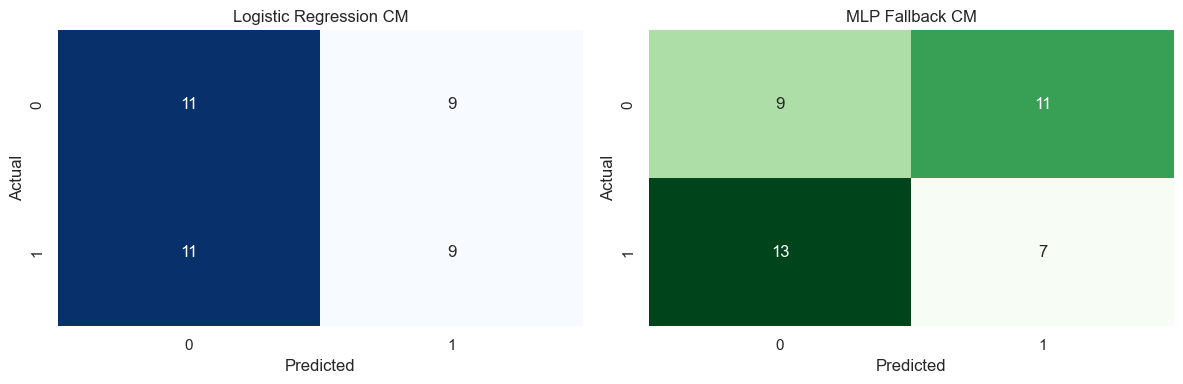

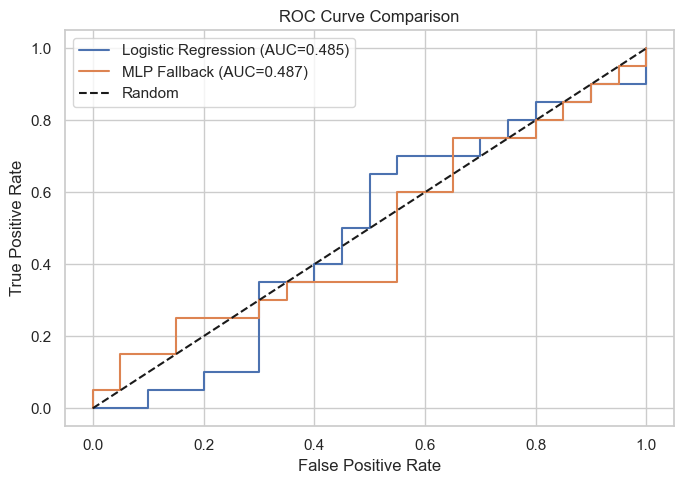

In [11]:
# Final metrics comparison
results_df = pd.DataFrame([lr_metrics, cnn_metrics])
display(results_df.style.format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1':'{:.4f}','ROC-AUC':'{:.4f}'}))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Logistic Regression CM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title(f"{cnn_metrics['Model']} CM")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})')
plt.plot(fpr_cnn, tpr_cnn, label=f"{cnn_metrics['Model']} (AUC={auc_cnn:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()
